In [194]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [151]:
dataset=pd.read_csv(r"C:\Users\LENOVO\Desktop\Learning\Deep Learning\Bank_churn_modelling.csv")

In [152]:
dataset=dataset.drop(columns=['RowNumber','CustomerId','Surname','Geography','Gender'],axis=1)

In [153]:
dataset.head(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0


In [154]:
dataset.isnull().sum()

CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [155]:
input_data=dataset.iloc[:,:-1]
output_data=dataset.iloc[:,-1]

In [156]:
ss=StandardScaler()
ss.fit_transform(input_data)

array([[-0.32622142,  0.29351742, -1.04175968, ...,  0.64609167,
         0.97024255,  0.02188649],
       [-0.44003595,  0.19816383, -1.38753759, ..., -1.54776799,
         0.97024255,  0.21653375],
       [-1.53679418,  0.29351742,  1.03290776, ...,  0.64609167,
        -1.03067011,  0.2406869 ],
       ...,
       [ 0.60498839, -0.27860412,  0.68712986, ..., -1.54776799,
         0.97024255, -1.00864308],
       [ 1.25683526,  0.29351742, -0.69598177, ...,  0.64609167,
        -1.03067011, -0.12523071],
       [ 1.46377078, -1.04143285, -0.35020386, ...,  0.64609167,
        -1.03067011, -1.07636976]], shape=(10000, 8))

In [157]:
ss=StandardScaler()
input_data=pd.DataFrame(ss.fit_transform(input_data),columns=input_data.columns)

In [158]:
input_data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276
...,...,...,...,...,...,...,...,...
9995,1.246488,0.007457,-0.004426,-1.225848,0.807737,0.646092,-1.030670,-0.066419
9996,-1.391939,-0.373958,1.724464,-0.306379,-0.911583,0.646092,0.970243,0.027988
9997,0.604988,-0.278604,0.687130,-1.225848,-0.911583,-1.547768,0.970243,-1.008643
9998,1.256835,0.293517,-0.695982,-0.022608,0.807737,0.646092,-1.030670,-0.125231


In [89]:
input_data.shape

(10000, 8)

In [245]:
x_train,x_test,y_train,y_test=train_test_split(input_data,output_data,test_size=0.2,random_state=10)

In [246]:
x_train.shape

(8000, 8)

In [247]:
import tensorflow

In [265]:
from keras.layers import Dense
from keras.regularizers import L2
from keras.models import Sequential
from keras.callbacks import EarlyStopping

In [249]:
ann=Sequential()

In [304]:
ann.add(Dense(6,input_dim=8,activation="relu",kernel_regularizer=L2(l2=0.01)))
ann.add(Dense(4,activation="relu"))
ann.add(Dense(2,activation="relu"))
ann.add(Dense(1,activation="sigmoid"))


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [305]:
ann.compile(optimizer='adam',loss="binary_crossentropy",metrics=['accuracy'])

EARLYSTOPPING METHOD


In [306]:
ann.fit(x_train,y_train,batch_size=100,epochs=50,validation_data=(x_test,y_test),callbacks=EarlyStopping())

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7981 - loss: 0.6537 - val_accuracy: 0.7890 - val_loss: 0.5985
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7981 - loss: 0.5469 - val_accuracy: 0.7890 - val_loss: 0.5291
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7981 - loss: 0.5144 - val_accuracy: 0.7890 - val_loss: 0.5245
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7981 - loss: 0.5112 - val_accuracy: 0.7890 - val_loss: 0.5223
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7981 - loss: 0.5093 - val_accuracy: 0.7890 - val_loss: 0.5208
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7981 - loss: 0.5080 - val_accuracy: 0.7890 - val_loss: 0.5195
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7981 - loss: 0.5068 - val_accuracy: 0.7890 - val_loss: 0.5189
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7981 - loss: 0.5059 - val_accuracy: 0.7890 - 

In [307]:
train_accuracy=ann.history.history["accuracy"]
test_accuracy=ann.history.history["val_accuracy"]

In [308]:
len(test_accuracy)

11

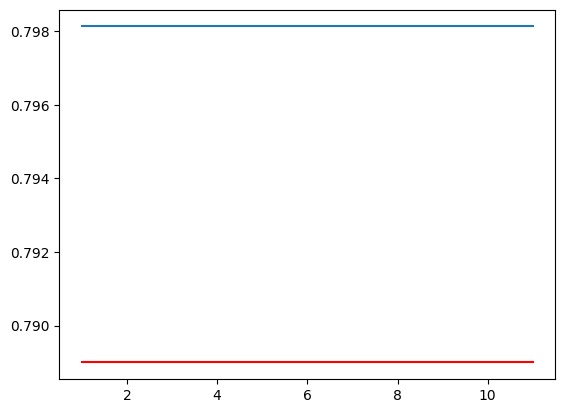

In [310]:
plt.plot([i for i in range(1,12)],train_accuracy)
plt.plot([i for i in range(1,12)],test_accuracy,c='red')
plt.show()

In [311]:
prd1=ann.predict(x_train)
prd_data1=[]
for i in prd1:
    if i[0]>0.5:
        prd_data1.append(1)
    else:
        prd_data1.append(0)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [312]:
prd=ann.predict(x_test)
prd_data=[]
for i in prd:
    if i[0]>0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [313]:
from sklearn.metrics import accuracy_score

In [314]:
accuracy_score(y_test,prd_data)*100

78.9

In [315]:
accuracy_score(y_train,prd_data1)*100

79.8125